# Problem Statement

## Background
Lenders lose money when borrowers default, but rejecting too many applicants means losing good customers. A model that estimates default risk helps a lender make this trade-off consistently instead of relying on judgment alone.

## Objective
Build a binary classification model that predicts whether a loan will default (`loan_status`: 1 = default, 0 = repaid) from borrower and loan characteristics.

## Intended Use
The model is meant to be used **after a loan has been priced**, so the interest rate (`loan_int_rate`) is known. It supports risk assessment at that stage. It is not designed to score raw applicants before a rate has been assigned.

## Data
- 32,581 loan records with 12 columns: borrower details (income, home ownership, employment length, credit history length, prior default on file) and loan details (amount, purpose, grade, interest rate, loan-to-income ratio).
- About 22% of loans are defaults, so the classes are imbalanced.
- The data contains missing values (`person_emp_length`, `loan_int_rate`), duplicate rows, and impossible values (e.g. ages above 100, employment lengths above 100 years) that need cleaning.

## Approach
1. Explore and clean the data (outliers, duplicates, missing values).
2. Remove features that are legally sensitive (`person_age`) or assigned by the lender (`loan_grade`).
3. Compare a logistic regression baseline, a decision tree, XGBoost, and a neural network, handling class imbalance with class weights.
4. Tune the best-performing models with cross-validated grid search.
5. Evaluate on a held-out test set and export the final pipeline.

## Evaluation
Accuracy alone is misleading with imbalanced classes. Models are compared on **F1, precision, recall and ROC-AUC** for the default class.
- **Recall:** the share of actual defaulters the model catches.
- **Precision:** the share of flagged borrowers who really default.

## Success Criteria
A model that clearly outperforms the logistic regression baseline on F1 and AUC, with a recall and precision balance that suits the lender's cost of missed defaults versus rejected good borrowers.

## Assumptions and Limitations
- The default decision threshold of 0.5 is used. A real deployment should set it from the actual costs of each error type.
- Predicted probabilities are not calibrated because of class weighting.
- The dataset does not say which lender or time period it covers, so results may not transfer to other populations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("credit_risk_dataset.csv/credit_risk_dataset.csv")

# length and info
print("Length: ", df.shape[0])
print("Features: ", df.shape[1])

print("Feature names: ", df.columns.to_list())
df.head()

Length:  32581
Features:  12
Feature names:  ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [4]:
# checking for nan values
print("NAN cols in Percent: ")
print(round(df.isna().sum() / df.shape[0] * 100,2))

NAN cols in Percent: 
person_age                    0.00
person_income                 0.00
person_home_ownership         0.00
person_emp_length             2.75
loan_intent                   0.00
loan_grade                    0.00
loan_amnt                     0.00
loan_int_rate                 9.56
loan_status                   0.00
loan_percent_income           0.00
cb_person_default_on_file     0.00
cb_person_cred_hist_length    0.00
dtype: float64


In [5]:
# checking for duplicated values
duplicates = df.duplicated().sum()
print("Number of Duplicates: ", duplicates)

Number of Duplicates:  165


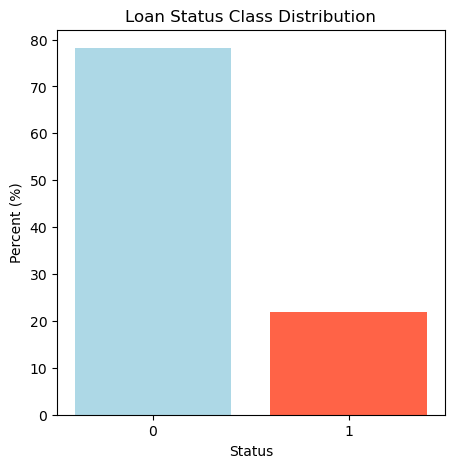

In [6]:
# checking for class imbalance with our target variable (loan_status)
target_dist = df.loan_status.value_counts() / df.shape[0] * 100

plt.figure(figsize=(5,5))
plt.bar(target_dist.index.astype(str), target_dist, color=["lightblue", "tomato"])
plt.title("Loan Status Class Distribution")
plt.xlabel("Status")
plt.ylabel("Percent (%)")
plt.show()

person_age skewness:  2.58
person_income skewness:  32.87
person_emp_length skewness:  2.61
loan_amnt skewness:  1.19
loan_int_rate skewness:  0.21
loan_percent_income skewness:  1.06
cb_person_cred_hist_length skewness:  1.66


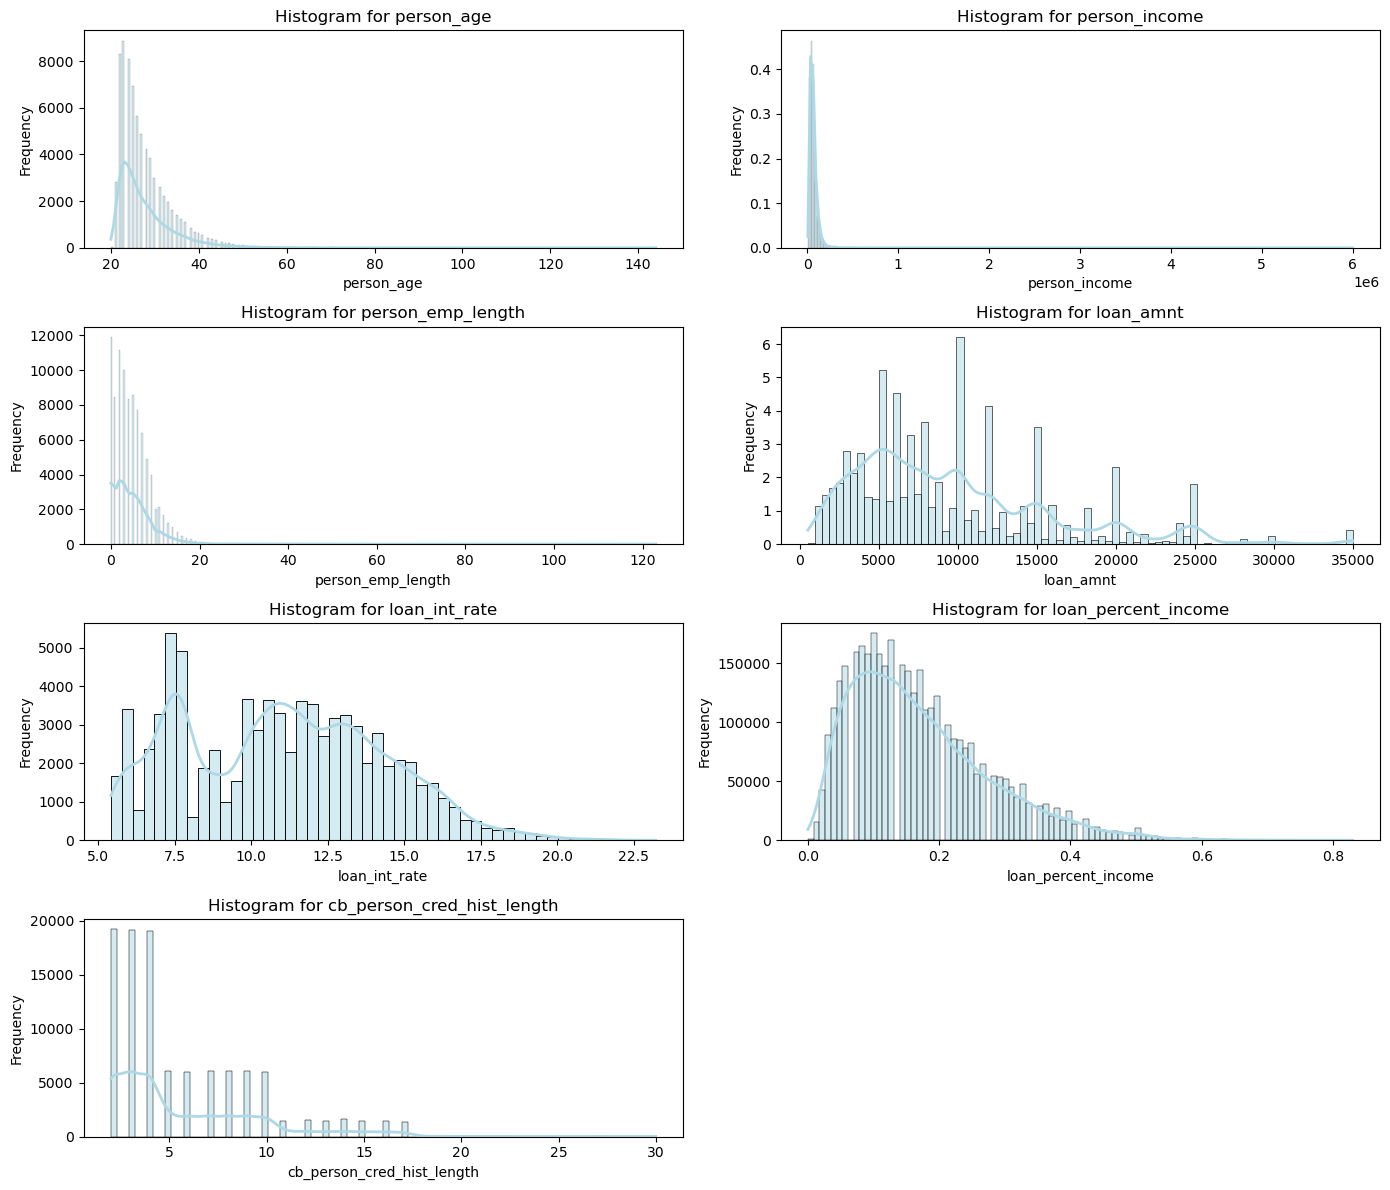

In [7]:
# exploring distribution of numeric 
# numeric cols
numeric_cols = df.select_dtypes(include="number").columns.drop("loan_status")
numeric_cols

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14,12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    print(f"{col} skewness:  {abs(df[col].skew()):.2f}")
    sns.histplot(
        df,
        kde=True,
        x = col,
        color="lightblue",
        edgecolor="black",
        line_kws={"color": "red", "linewidth": 2},
        stat="frequency",
        ax= axes[i]
    )
    axes[i].set_xlabel(f"{col}")
    axes[i].set_title(f"Histogram for {col}")
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

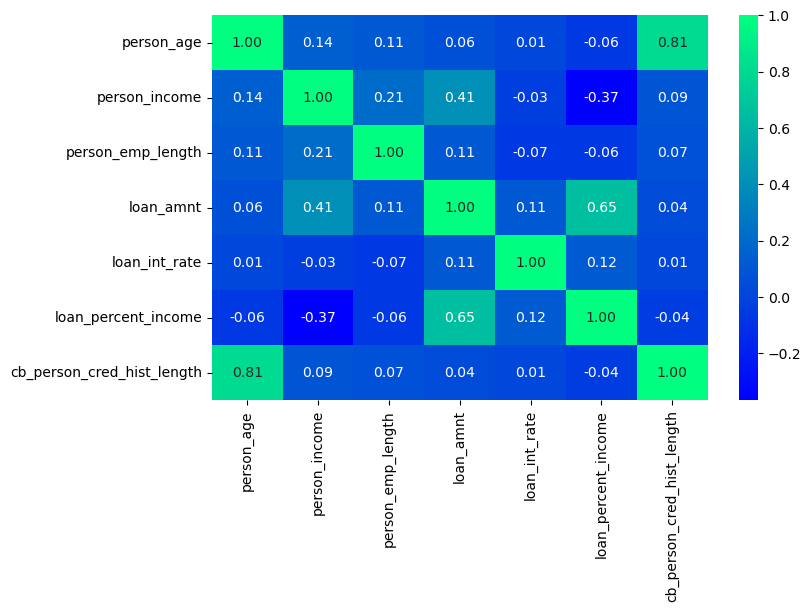

In [8]:
# checking correlation between features
numeric_cols = df.select_dtypes(include="number").columns.drop("loan_status")
corr_matrix = df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(8,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="winter"
)
plt.show()

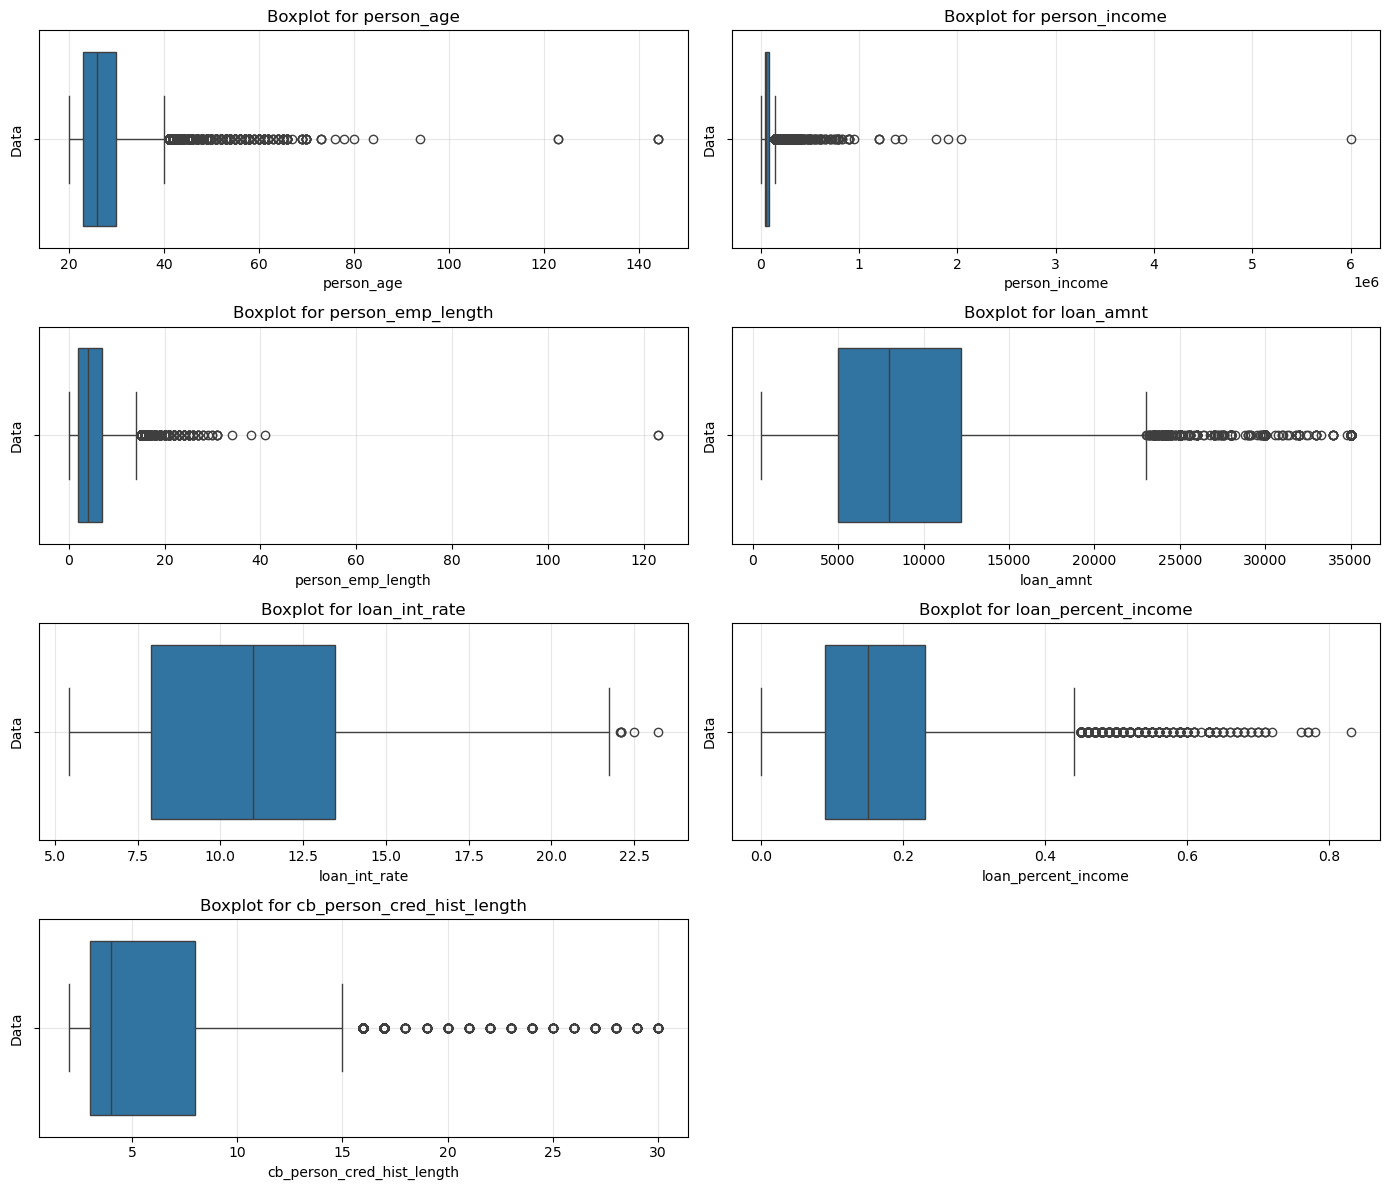

In [9]:
# checking for outliers
numeric_cols = df.select_dtypes(include="number").columns.drop("loan_status")

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14,12))
axes = axes.flatten()
for i,col in enumerate(numeric_cols):
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i]
    )
    axes[i].set_title(f"Boxplot for {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Data")
    axes[i].grid(alpha=0.3)
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


- Several numerical features are **right-skewed**, suggesting the use of transformations such as log or Yeo-Johnson, particularly for models like Logistic Regression.
- The dataset contains missing values:
  - `person_emp_length`: **2.75%**
  - `loan_int_rate`: **9.56%**
- The target variable `loan_status` is **imbalanced**, making accuracy alone potentially misleading.
- **Precision, recall, F1-score, and PR-AUC** should be prioritized for model evaluation.
- **SMOTE or undersampling** can be tested to address class imbalance, but only on the training data to avoid data leakage.

## Data Cleaning and Preprocessing

In [10]:
# inspecting outliers in person_age
df[df.person_age >= 100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


First we will remove outliers by **person_age**, as in today's world it's very rare to see people who `lives more than 100`. # we will likely remove these as they are very extreme and rare for this projects use case.



In [11]:
# setting up copy for our dataset
clean_df = df.copy()

age_outliers_idx = clean_df[clean_df.person_age >= 100].index

print(f"Before removing outliers: {clean_df.shape}")
clean_df.drop(index=age_outliers_idx, inplace=True)
print(f"After removing outliers: {clean_df.shape}")
clean_df.reset_index(drop=True).head()

Before removing outliers: (32581, 12)
After removing outliers: (32576, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Next we will be inspecting **person_age** and **person_emp_length** as a person with very low age should not be having high employment length like 140.

From the above scatter plot, we can see that person_age lower than 30 has unreasonably higher person_emp_length( > 120). Hence we will be removing these outliers from our dataset since it causes skewness in our dataset 

In [12]:
# filtering person age < person employment length
clean_df[clean_df.person_age < clean_df.person_emp_length]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [13]:
emp_length_outlier_idx = clean_df[(clean_df.person_age < 40) & (clean_df.person_emp_length > 100)].index

print(f"Before removing outliers: {clean_df.shape}")
clean_df.drop(index=emp_length_outlier_idx, inplace=True)
print(f"After removing outliers: {clean_df.shape}")
clean_df.reset_index(drop=True).head()

Before removing outliers: (32576, 12)
After removing outliers: (32574, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


- Between `person_age` and `cb_person_cred_hist_length`, we will retain `cb_person_cred_hist_length` as it is more directly relevant to credit risk, while excluding age due to potential fairness and regulatory concerns.
- We will drop `loan_grade` because it may be strongly related to `loan_int_rate`, potentially introducing redundant information.
- For our use case, we aim to assess **default risk in relation to the interest rate offered to the borrower**.

In [14]:
# removing  person_age, loan_grade and loan_int_rate
print(f"Before removing cols: {clean_df.shape}")
clean_df = clean_df.drop(["person_age", "loan_grade"], axis=1)
print(f"After removing cols: {clean_df.shape}")

Before removing cols: (32574, 12)
After removing cols: (32574, 10)


skewness in person_income : 9.76
skewness in person_emp_length : 1.25
skewness in loan_amnt : 1.19
skewness in loan_int_rate : 0.21
skewness in loan_percent_income : 1.06
skewness in cb_person_cred_hist_length : 1.66


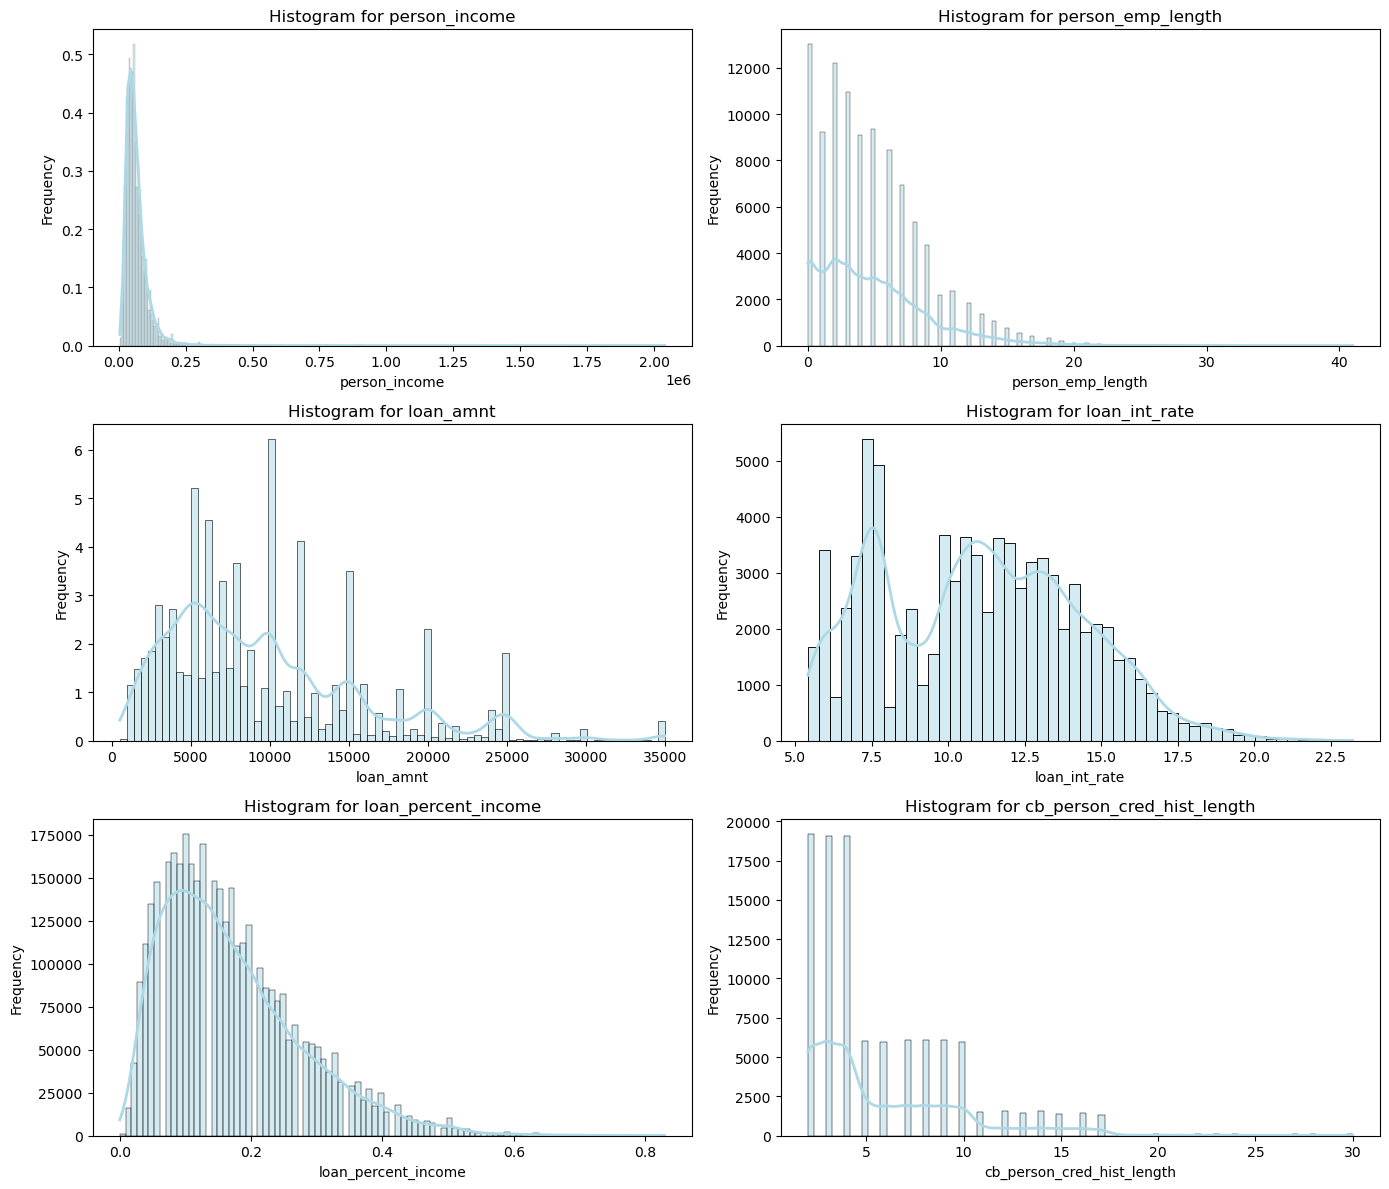

In [15]:
# exploring distribution of numeric varaibles after removing outliers 
# numeric cols
numeric_cols = clean_df.select_dtypes(include="number").columns.drop("loan_status")
numeric_cols

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14,12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    print(f"skewness in {col} : {abs(clean_df[col].skew()):.2f}")
    sns.histplot(
        clean_df,
        kde=True,
        x = col,
        color="lightblue",
        edgecolor="black",
        line_kws={"color": "red", "linewidth": 2},
        stat="frequency",
        ax= axes[i]
    )
    axes[i].set_xlabel(f"{col}")
    axes[i].set_title(f"Histogram for {col}")
plt.tight_layout()
plt.show()

In [16]:
# removing duplicates from the dataset
duplcates_idx = clean_df[clean_df.duplicated()].index
print("Number of Duplicates: ", len(duplcates_idx))

print(f"Before removing duplicates: {clean_df.shape}")
clean_df.drop_duplicates(inplace=True) 
print(f"After removing duplicates: {clean_df.shape}")
clean_df.reset_index(drop=True).head()

Number of Duplicates:  168
Before removing duplicates: (32574, 10)
After removing duplicates: (32406, 10)


,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
1,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
2,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
3,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4
4,9900,OWN,2.0,VENTURE,2500,7.14,1,0.25,N,2


In [17]:
# splitting independent and dependent variables
X = clean_df.drop("loan_status", axis=1)
y = clean_df["loan_status"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=23,
    stratify=y
)

print("X_train", X_train.shape)
print("y_train", y_train.shape)

X_train (25924, 9)
y_train (25924,)


In [18]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    FunctionTransformer,
    StandardScaler
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# 1. Numeric columns that need log transformation
log_cols = [
    "person_income",
    "loan_amnt",
    "person_emp_length",
    "cb_person_cred_hist_length",
    "loan_percent_income"
]

# 2. Numeric columns that should not be log-transformed
other_num_cols = ["loan_int_rate"]

# 3. Numeric pipeline with log transformation
log_num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

# 4. Numeric pipeline without log transformation
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 5. Ordinal categorical pipeline
# grade_transformer = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("ordinal", OrdinalEncoder(
#         categories=[["A", "B", "C", "D", "E", "F", "G"]],
#         handle_unknown="use_encoded_value",
#         unknown_value=-1
#     )),
#     ("scaler", StandardScaler())
# ])

# 6. Nominal categorical pipeline
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("oh_encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

# 7. Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("log_num", log_num_transformer, log_cols),
        ("num", num_transformer, other_num_cols),
        # ("grade", grade_transformer, ["loan_grade"]),
        ("cat", cat_transformer, [
            "loan_intent",
            "cb_person_default_on_file",
            "person_home_ownership"
        ])
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_num', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [19]:
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    f1_score, 
    recall_score, 
    precision_score, 
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

def evaluate(name, y_preds, y_test, y_probs):
    # roc curve
    fpr, tpr, threshold = roc_curve(y_test, y_probs)
    # auc score
    auc = roc_auc_score(y_test, y_probs)
    
    result = {
        "model": name,
        "accuracy": round(accuracy_score(y_test, y_preds),3),
        "precision": round(precision_score(y_test, y_preds),3),
        "recall": round(recall_score(y_test, y_preds),3),
        "f1": round(f1_score(y_test, y_preds),3),
        "auc": round(auc,3)
    }
    print(classification_report(y_test, y_preds))

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
    axes = axes.flatten()
    
    # display confusion matrix 
    c_matrix=confusion_matrix(y_test, y_preds)
    disp=ConfusionMatrixDisplay(c_matrix, display_labels=[0,1])
    disp.plot(ax=axes[0])
    axes[0].set_title(f"Confusion Matrix for - {name}")
    
    # roc curve 
    axes[1].plot(fpr, tpr, label=f"AUC score: {auc:.3f}")
    axes[1].plot([0,1], [0,1], linestyle="--", label="random classifier")
    axes[1].set_title(f"ROC curve for - {name}")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].grid(alpha=0.3)
    axes[1].legend()
    
    fig.suptitle(f"{name} Evaluation", fontsize=14)
    plt.tight_layout()
    # Save figure
    fig.savefig(
        f"plots/{name}_evaluation.png",
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)

    return result

In [20]:
results = []

def add_results(result):
    if not any(r["model"] == result["model"] for r in results):
        results.append(result)

## Logistic Regression (Baseline) 

In [21]:
from sklearn.linear_model import LogisticRegression

# creating our first baseline model

logistic_clf = Pipeline([
    ("preprocessor" ,preprocessor),
    ("logistic", LogisticRegression(solver="liblinear", l1_ratio=1, class_weight="balanced"))
])
logistic_clf.fit(X_train, y_train)
print(f"Training Score: {logistic_clf.score(X_train, y_train):.2f}")

Training Score: 0.78


              precision    recall  f1-score   support

           0       0.92      0.78      0.84      5064
           1       0.49      0.77      0.60      1418

    accuracy                           0.78      6482
   macro avg       0.71      0.77      0.72      6482
weighted avg       0.83      0.78      0.79      6482



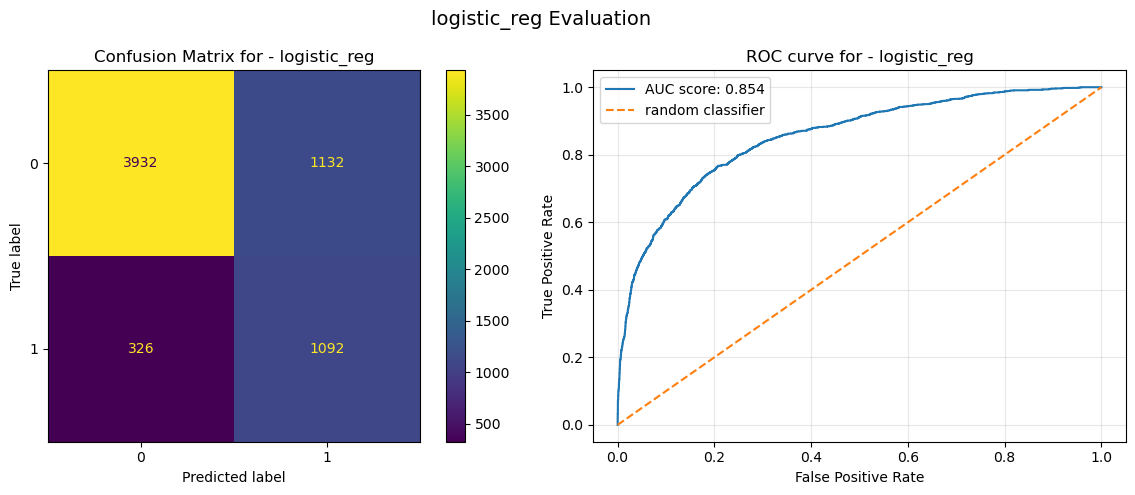

In [22]:
y_preds = logistic_clf.predict(X_test)
y_probs = logistic_clf.predict_proba(X_test)[:,1]
add_results(evaluate("logistic_reg", y_preds, y_test, y_probs))

**Baseline model (Logistic Model)** :
- The logistic baseline model struggles in correctly predicting default risk customers with low score in precision(0.49) and overall only shows a f1 score of 0.60.
- The model struggles in training set, suggesting a better model for prediction.

### Decision Tree (baseline model)

In [23]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("decision_tree", DecisionTreeClassifier(max_depth=5, class_weight="balanced")),
])

decision_tree_model.fit(X_train, y_train)


decision_tree_model.score(X_train, y_train)

0.8661471995062491

==============Decision Tree ================
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      5064
           1       0.67      0.72      0.69      1418

    accuracy                           0.86      6482
   macro avg       0.79      0.81      0.80      6482
weighted avg       0.87      0.86      0.86      6482



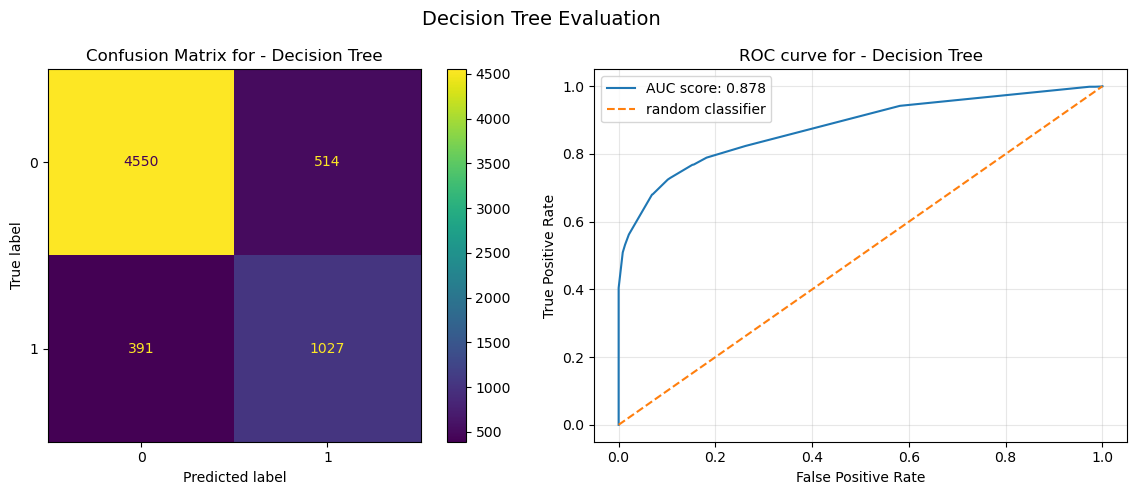

In [24]:
print("==============Decision Tree ================")
y_preds = decision_tree_model.predict(X_test)
y_probs = decision_tree_model.predict_proba(X_test)[:,1]
add_results(evaluate("Decision Tree", y_preds, y_test, y_probs))

**Baseline Decision Tree**: 
- The decision tree performs much better than the Logistic Regression, as it considerably shows improvements in identifying defaulters with an AUC score 0.87.
- The model also acquired better recall, precision and f1 score. 

In [25]:
from xgboost import XGBClassifier

# class weighting
scale_pos_weight = (
    (y_train==0).sum() / (y_train==1).sum()
)

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb_classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)
xgb_model.score(X_train, y_train)

0.9539037185619503

In [26]:
xgb_model.score(X_test, y_test)

0.9032705954952175

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      5064
           1       0.78      0.79      0.78      1418

    accuracy                           0.90      6482
   macro avg       0.86      0.86      0.86      6482
weighted avg       0.90      0.90      0.90      6482



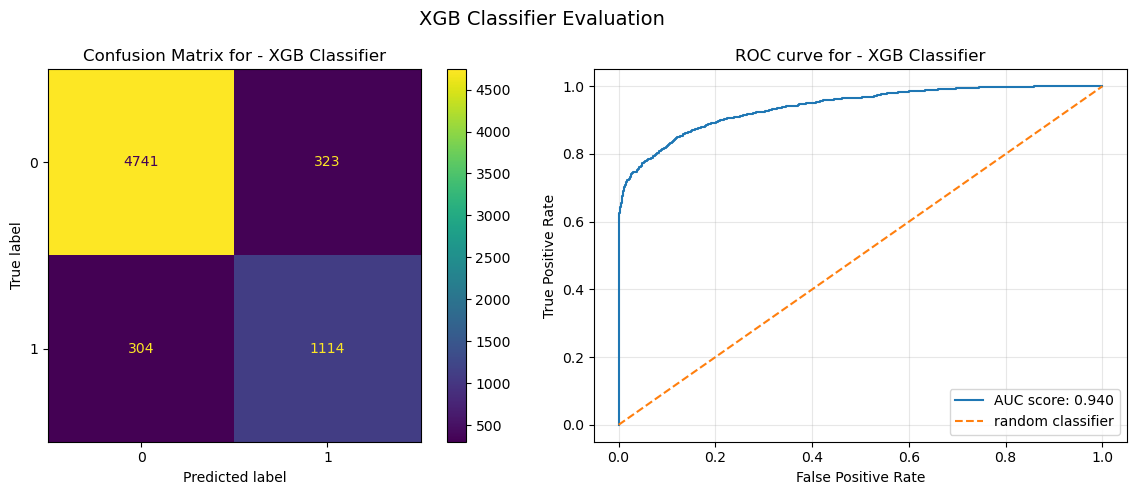

In [27]:
y_preds = xgb_model.predict(X_test)
y_probs = xgb_model.predict_proba(X_test)[:,1]
add_results(evaluate("XGB Classifier", y_preds, y_test, y_probs))

**XGB Classifier** : 
- Compared to our baseline model, XGBClassifier showed much better performance than our baseline models. It showed better precision and AUC score.
- Furtheremore, model showed great improvements in recall and precision where it scored 0.8 and 0.76 respectively for credit defaulters class.

In [28]:
# creating neural network
import tensorflow as tf
from tensorflow import keras

# dataset for neural network
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# defining our neural network
# number of classes
NB_Classes = 1

# creating a sequential network
nn_model = keras.models.Sequential()

# adding first layer
nn_model.add(keras.layers.Dense(
    32,
    input_shape=(X_train_preprocessed.shape[1],),
    name="hidden-layer1",
    activation="relu"
))

# adding second layer
nn_model.add(keras.layers.Dense(
    24,
    name="hidden-layer2",
    activation="relu"
))

# outplut layer
nn_model.add(keras.layers.Dense(
    NB_Classes,
    name="output_layer",
    activation="sigmoid"
))

nn_model.compile(loss="binary_crossentropy", metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ])
nn_model.summary()

C:\Users\Yogsh\Desktop\ML-projects\env\Lib\site-packages\keras\src\layers\core\dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden-layer1 (Dense)                │ (None, 32)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden-layer2 (Dense)                │ (None, 24)                  │             792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 1)                   │              25 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,329 (5.19 KB)

 Trainable params: 1,329 (5.19 KB)

 Non-trainable params: 0 (0.00 B)

{np.int64(0): np.float64(0.6399723511405154), np.int64(1): np.float64(2.286067019400353)}
Epoch 1/48
730/730 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7694 - auc: 0.8588 - loss: 0.4684 - precision: 0.4828 - recall: 0.7952 - val_accuracy: 0.8322 - val_auc: 0.8660 - val_loss: 0.3922 - val_precision: 0.6053 - val_recall: 0.7111
Epoch 2/48
730/730 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8168 - auc: 0.8896 - loss: 0.4142 - precision: 0.5568 - recall: 0.7869 - val_accuracy: 0.8504 - val_auc: 0.8735 - val_loss: 0.3754 - val_precision: 0.6457 - val_recall: 0.7284
Epoch 3/48
730/730 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8282 - auc: 0.8956 - loss: 0.4013 - precision: 0.5784 - recall: 0.7848 - val_accuracy: 0.8515 - val_auc: 0.8782 - val_loss: 0.3682 - val_precision: 0.6478 - val_recall: 0.7318
Epoch 4/48
730/730 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8350 - auc: 0.8992 - loss: 0.3927 - precision: 0.5926 - recall: 0.7814 - val_accuracy: 0.8511 - val_auc: 0.8819 - val_

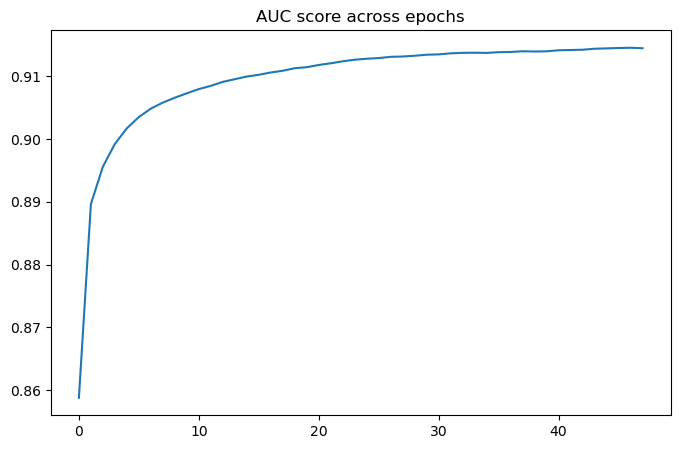

Neural Network Evaluation
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8820 - auc: 0.8990 - loss: 0.3329 - precision: 0.7428 - recall: 0.7045


[0.33291012048721313,
 0.8819808959960938,
 0.7427509427070618,
 0.7045133709907532,
 0.899017333984375]

In [29]:
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(33)
# verbose
VERBOSE = 1

BATCH_SIZE = 32
EPOCHS = 48

VALIDATION_SPLIT = 0.1

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

history = nn_model.fit(
    X_train_preprocessed,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    class_weight=class_weights,
    verbose=VERBOSE
)

pd.DataFrame(history.history)["auc"].plot(figsize=(8,5))
plt.title("AUC score across epochs")
plt.show()

print("Neural Network Evaluation")
nn_model.evaluate(X_test_preprocessed, y_test)

203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      5064
           1       0.74      0.70      0.72      1418

    accuracy                           0.88      6482
   macro avg       0.83      0.82      0.82      6482
weighted avg       0.88      0.88      0.88      6482



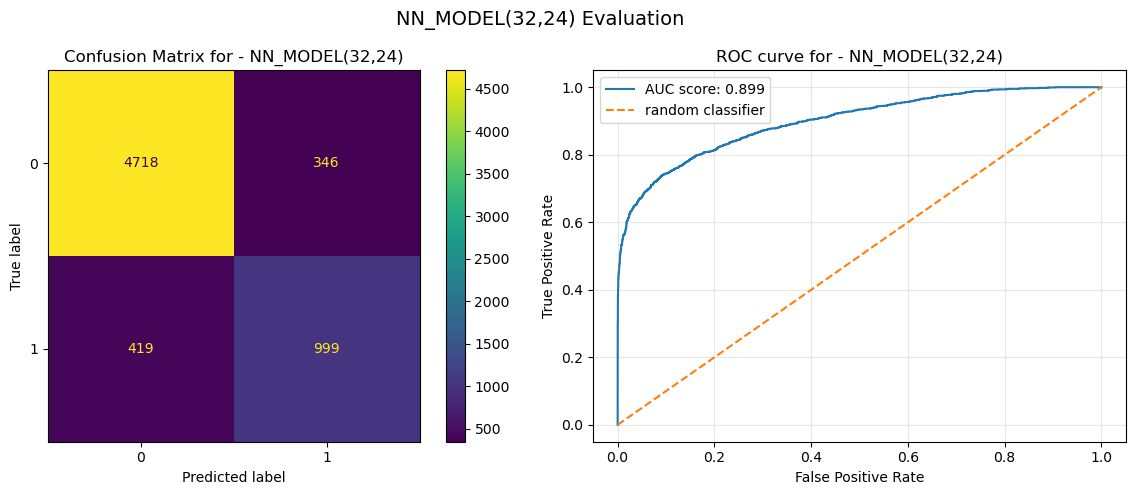

In [30]:
nn_prob = nn_model.predict(X_test_preprocessed)

nn_preds = (nn_prob >= 0.5).astype(int)

# nn_preds
add_results(evaluate("NN_MODEL(32,24)", nn_preds, y_test, nn_prob))

**Neural Network**:
- Neural network with a layer of 32 and 24 layers displays decent result.
- However, it struggles in correctly capturing and predicting credit defaulters with recall and precision score of 0.72 and 0.71 respectively.

## Hyper tuning our models

In [54]:
from sklearn.model_selection import RandomizedSearchCV
np.random.seed(12)

scale_pos_weight = (
    (y_train == 0).sum()/
    (y_train == 1).sum()
)

model_params = [
    {
        "model": LogisticRegression(
            random_state=12,
            solver="lbfgs",
            class_weight="balanced"
        ),
        "grid": {
            "model__penalty": ["l2"],
            "model__C": [0.01, 0.1, 1.0, 10]
        }
    },

    {
        "model": DecisionTreeClassifier(
            criterion="entropy",
            random_state=22,
            class_weight="balanced"
        ),
        "grid": {
            "model__max_depth": [4, 5, 8],
            "model__min_samples_split": [2, 8],
            "model__min_samples_leaf": [3, 5]
        }
    },

    {
        "model": XGBClassifier(
            random_state=32,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss"
        ),
       "grid": {
            "model__max_depth": [3, 5, 7],
            "model__min_child_weight": [1, 5, 10, 20],
            "model__n_estimators": [200, 400, 600, 1000],
            "model__learning_rate": [0.01, 0.1, 1.0],
            "model__reg_lambda": [0.0,1.0, 3.0, 8.0, 10.0],
        }
    }
]

for params in model_params:

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", params["model"])
    ])

    grid_search = RandomizedSearchCV(
        estimator=pipeline,
        n_iter=30,
        param_distributions=params["grid"],
        cv=5,
        scoring="f1",
        verbose=1,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    print(f"======= Model: {params['model'].__class__.__name__} =======")
    print(f"Best CV f1 score: {grid_search.best_score_:.4f}")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best Estimator: {grid_search.best_estimator_}")
    print("======================================")

C:\Users\Yogsh\Desktop\ML-projects\env\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=30. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 4 candidates, totalling 20 fits


C:\Users\Yogsh\Desktop\ML-projects\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Yogsh\Desktop\ML-projects\env\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 12 is smaller than n_iter=30. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


======= Model: LogisticRegression =======
Best CV f1 score: 0.6022
Best Parameters: {'model__penalty': 'l2', 'model__C': 0.1}
Best Estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('log_num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_income', 'loan_amnt',
                                  

From the above gird search cv we can clearly see that among the three models, XGBoost gave the best result with 0.80 recall score, followed by Decision Tree with 0.75 and Logistic Regression with 0.6 recall  score respectively.

**Best Model**:

model: XGBClassifier

In [55]:
# best estimator
best_classifier_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb_classifier", XGBClassifier(
        learning_rate = 0.1,
        max_depth = 7,
        n_estimators = 1000,
        min_child_weight = 5,
        scale_pos_weight = scale_pos_weight,
        reg_lambda=8.0,
        random_state=32,
        n_jobs=-1,
        eval_metric="logloss"
    ))
]
)

best_classifier_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('xgb_classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_num', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

In [56]:
# training score
training_score = best_classifier_pipeline.score(X_train, y_train)
print("Training Score: ", training_score)
# testing score
testing_score = best_classifier_pipeline.score(X_test, y_test)
print("Testing Score: ", testing_score)

Training Score:  0.9851874710692794
Testing Score:  0.9092872570194385


              precision    recall  f1-score   support

           0       0.94      0.94      0.94      5064
           1       0.80      0.78      0.79      1418

    accuracy                           0.91      6482
   macro avg       0.87      0.86      0.87      6482
weighted avg       0.91      0.91      0.91      6482



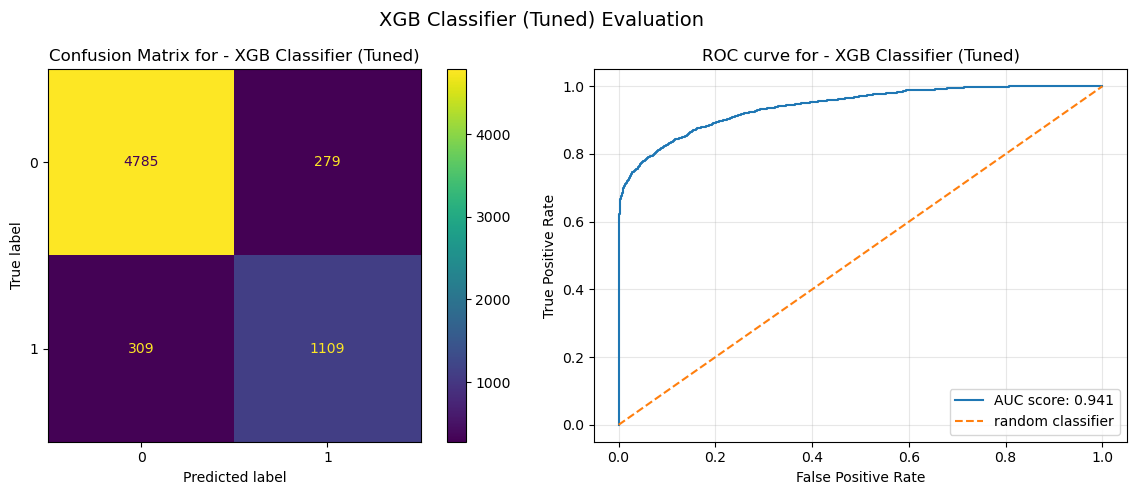

In [58]:
y_preds = best_classifier_pipeline.predict(X_test)
y_probs = best_classifier_pipeline.predict_proba(X_test)[:,1]

# best estimator result
add_results(evaluate("XGB Classifier (Tuned)",y_preds, y_test, y_probs))
# evaluate("XGB (Tuned)", y_preds, y_test, y_probs)

In [71]:
# feature importance for credit risk prediction
# importances= best_classifier_pipeline[:-1].feature_importances
features = best_classifier_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = best_classifier_pipeline.named_steps["xgb_classifier"].feature_importances_

feature_importance = pd.DataFrame(importances, index=features, columns=["values"])
feature_importance.sort_values(by="values",ascending=False, inplace=True)
feature_importance
feature_importance.to_csv("model/xgb_clf_feature_imp.csv")

In [72]:
feature_importance

,values
cat__person_home_ownership_OWN,0.194671
cat__loan_intent_VENTURE,0.124486
cat__person_home_ownership_RENT,0.123881
log_num__loan_percent_income,0.119131
cat__loan_intent_HOMEIMPROVEMENT,0.082887
num__loan_int_rate,0.065646
log_num__person_income,0.053516
cat__loan_intent_EDUCATION,0.044777
cat__loan_intent_MEDICAL,0.044410
cat__loan_intent_PERSONAL,0.039802


In [61]:
results_df = pd.DataFrame(results)
results_df.set_index("model", inplace=True)
results_df.sort_values(by="f1", ascending=False)
results_df.to_csv("model/results.csv")

,accuracy,precision,recall,f1,auc
model,,,,,
XGB Classifier (Tuned),0.909,0.799,0.782,0.790,0.941
XGB Classifier,0.903,0.775,0.786,0.780,0.940
"NN_MODEL(32,24)",0.882,0.743,0.705,0.723,0.899
Decision Tree,0.860,0.666,0.724,0.694,0.878
logistic_reg,0.775,0.491,0.770,0.600,0.854


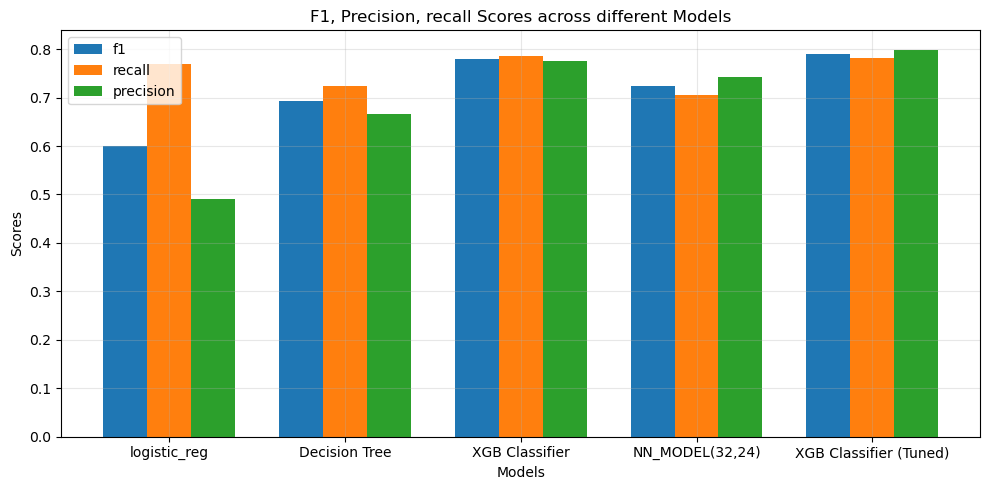

In [62]:
x = np.arange(len(results_df.index))
width= 0.25

plt.figure(figsize=(10,5))
plt.bar(
    x - width,
    height=results_df["f1"],
    width= width,
    label="f1"
)
plt.bar(
    x,
    height=results_df["recall"],
    width= width,
    label="recall"
)
plt.bar(
    x + width,
    height=results_df["precision"],
    width= width,
    label="precision"
)
plt.legend()
plt.xticks(x, results_df.index)
plt.xlabel("Models")
plt.ylabel("Scores")
plt.title("F1, Precision, recall Scores across different Models")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.savefig("plots/model_scores.png")
plt.show()


- The above bar chart shows distribution of f1, recall and precision of various models we modeled so far on our dataset. Based on that the most balanced score was obtained by XGBClassifier (Tuned), followed by XGB Classifier(Untuned) and neural network (32, 32). 

- Overall, the XGB Classifier(Tuned) has an overall f1 score of **79%**, has the ability to capture (recall) credit risk customer by **78%** and ability to predict (precision) risk customer by **79%**.

- The model overall shows good class seperation with a AUC score of **94.1%** and has an overall accuracy of **90.9**.

In [66]:
# making some predictions
samples = pd.DataFrame([
    {
    "person_income": 30000,
    "person_home_ownership": "RENT",
    "person_emp_length": 1.0,
    "loan_intent": "PERSONAL",
    "loan_amnt": 15000,
    "loan_int_rate": 18.5,
    "cb_person_default_on_file": "Y",
    "loan_percent_income": 0.5,
    "cb_person_cred_hist_length": 3
    }, # customer with high debt --- likely to default,
    {
    "person_income": 150000,
    "person_home_ownership": "RENT",
    "person_emp_length": 2.0,
    "loan_intent": "HOMEIMPROVEMENT",
    "loan_amnt": 50000,
    "loan_int_rate": 2.8,
    "cb_person_default_on_file": "Y",
    "loan_percent_income": 0.33,
    "cb_person_cred_hist_length": 3
    },
    {
    "person_income": 100000,
    "person_home_ownership": "OWN",
    "person_emp_length": 10.0,
    "loan_intent": "VENTURE",
    "loan_amnt": 10000,
    "loan_int_rate": 6.5,
    "cb_person_default_on_file": "N",
    "loan_percent_income": 0.01,
    "cb_person_cred_hist_length": 12
    }, # low risk borrower
    {
    "person_income": 100000,
    "person_home_ownership": "RENT",
    "person_emp_length": 12.0,
    "loan_intent": "HOMEIMPROVEMENT",
    "loan_amnt": 50000,
    "loan_int_rate": 10.5,
    "cb_person_default_on_file": "N",
    "loan_percent_income": 0.2,
    "cb_person_cred_hist_length": 10
    }, #high income with high loan
])
prediction = best_classifier_pipeline.predict(samples)
prediction_prob = best_classifier_pipeline.predict_proba(samples)[:,0]
prob_li = np.array([np.round(pred,4) * 100 for pred in prediction_prob])

print(f"prediction: {prediction}")
print(f"Probability will not default:\n {prob_li}")

prediction: [1 1 0 0]
Probability will not default:
 [  0.        27.970001 100.        97.729996]


In [67]:
# exporting our model for future use
import pickle

with open("model/xgb_clf.pkl", "wb") as file:
    pickle.dump(best_classifier_pipeline, file)
    print("Model Successfully exported")

Model Successfully exported
